In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sunpy.visualization.colormaps as sunpycm
from loguru import logger as lgr_logger
from omegaconf import OmegaConf

from sdofmv2.core import MAE, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-10 01:29:10.389 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:29:10.390 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:29:10.390 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:29:10.391 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:29:10.391 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:29:10.392 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [4]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [5]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

model_no_mask = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
model_no_mask.masking_ratio = 0
lgr_logger.info(f"masking ratio of sdofmv2: {model_no_mask.masking_ratio}")


2026-03-10 01:29:13.002 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5
2026-03-10 01:29:14.187 | INFO     | __main__:<module>:13 - masking ratio of sdofmv2: 0


In [6]:
timestamps = ["2011-12-25 00:12:00"]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

In [7]:
model.eval()

with torch.no_grad():
    output = model(x_set)
    output_wo_mask = model_no_mask(x_set)


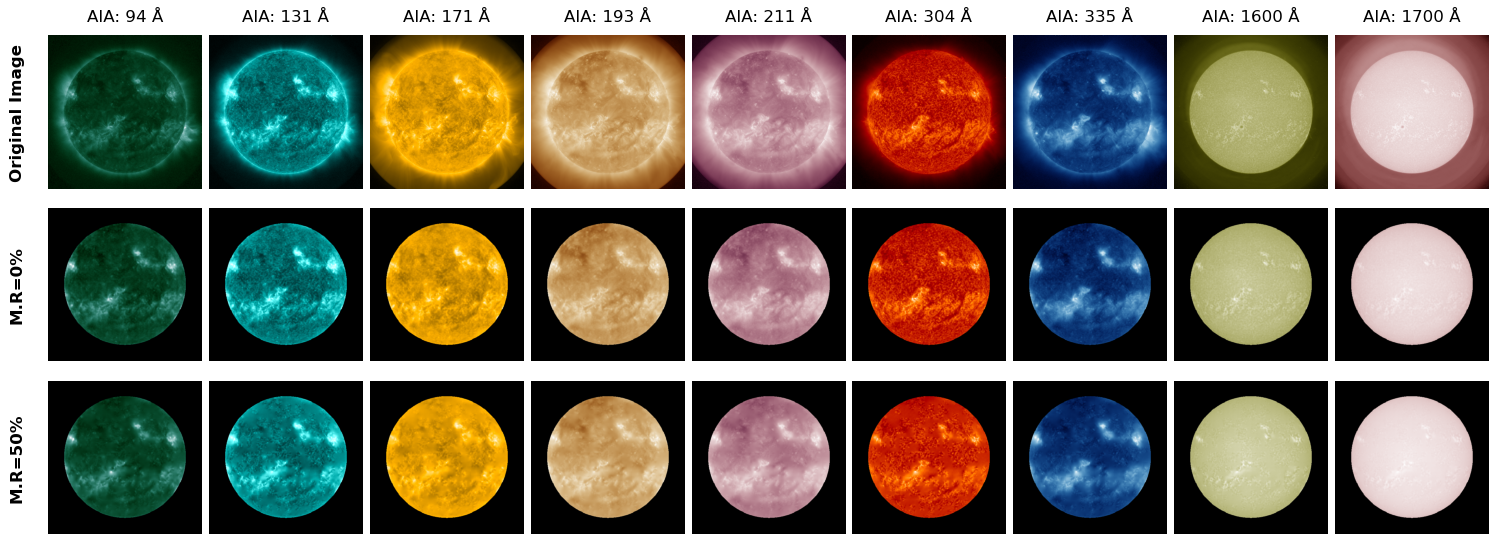

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(16, 6))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]

for i, col in enumerate(sort_ids):
    # --- Row 0: Original Image ---
    axes[0][i].imshow(x_set[0, col, 0, :, :], cmap=cms[col])
    axes[0][i].set_title(f"AIA: {ch_info[col]} Å", fontsize=12, pad=10)
    
    # --- Row 1: 0% Masking (Reconstruction) ---
    axes[1][i].imshow(output_wo_mask[0][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    
    # --- Row 2: 50% Masking (Inpainting/Prediction) ---
    axes[2][i].imshow(output[0][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    

row_info = [
    "Original Image", 
    "M.R=0%", # "Masking Ratio: \n 0%",   # Or "M.R. = 0.0"
    "M.R=50%" # "Masking Ratio: \n 50%"   # Or "M.R. = 0.5"
]

for row_idx in range(3):
    axes[row_idx][0].text(
        -0.2, 0.5,
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        fontweight='bold', # Added bold for better readability
        rotation=90,
        transform=axes[row_idx][0].transAxes 
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_AIA_results_mask_ratio_{ts}.png", dpi=300, bbox_inches="tight")
plt.show()